In [ ]:
import os

# --- Must be set before importing tensorflow ---
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # 0=all, 1=INFO, 2=WARNING, 3=ERROR only
os.environ["XLA_FLAGS"] = "--xla_cpu_multi_thread_eigen=false intra_op_parallelism_threads=1"
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"  # disable XLA JIT
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # optional: choose GPU

import warnings
import logging
import absl.logging
import tensorflow as tf

# Silence absl (used by XLA logs)
logging.getLogger("absl").setLevel(logging.ERROR)
absl.logging.set_verbosity(absl.logging.ERROR)

# Silence Python warnings
warnings.filterwarnings("ignore")

# Silence TensorFlow Python logs
tf.get_logger().setLevel("ERROR")
tf.autograph.set_verbosity(0)

# Disable JIT to reduce ptxas warnings
tf.config.optimizer.set_jit(False)

In [ ]:
import os, gc, json
import librosa
import numpy as np
import pandas as pd
import torch
import random
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer
)

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("DataFrame/processed_df.csv")
df["path"] = df["path"].apply(lambda p: p.replace("\\", "/"))

datasets_all = df["dataset"].unique()
print("Datasets:", datasets_all)

Datasets detected: ['RAVDESS' 'TESS' 'SAVEE' 'CREMA']


#### Apply augmentation to training dataframe

In [ ]:
# ============================================================
# 2. VISUALIZATION HELPERS (emotion-only, cleaner)
# ============================================================
missing = [p for p in df["path"] if not os.path.exists(p)]
print("Missing files:", len(missing))
missing[:10]

def plot_distribution(df, title):
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x="emotion", palette="tab10")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Missing files: 0


In [ ]:
# ============================================================
# 3. EMOTION-ONLY AUGMENTATION (separated per LODO case)
# ============================================================
def aug_noise(audio):
    return audio + np.random.normal(0, 0.005, len(audio))

def aug_gain(audio):
    return audio * np.random.uniform(0.8, 1.2)

def aug_time_stretch(audio):
    if len(audio) < 2: return audio
    return librosa.effects.time_stretch(audio, rate=np.random.uniform(0.9, 1.1))

AUGS = [aug_noise, aug_gain, aug_time_stretch]

# ------------------------------------------------------------
# Augment and balance train_df inside the isolated LODO folder
# ------------------------------------------------------------
def augment_and_balance(train_df):
    emotion_counts = train_df["emotion"].value_counts()
    max_count = emotion_counts.max()

    print("Before balancing:\n", emotion_counts)

    new_rows = []
    audio_cache = {}

    for emotion, count in emotion_counts.items():
        needed = max_count - count
        if needed == 0: continue

        src_rows = train_df[train_df["emotion"] == emotion]

        for i in tqdm(range(needed), desc=f"Aug {emotion}"):
            row = src_rows.sample(1).iloc[0]
            audio, sr = librosa.load(row["path"], sr=16000)
            aug_fn = random.choice(AUGS)
            aug_audio = aug_fn(audio)

            vpath = f"memory://{emotion}_{i}"
            audio_cache[vpath] = aug_audio

            new_rows.append({
                "dataset": row["dataset"],
                "path": vpath,
                "emotion": emotion
            })

    df_new = pd.concat([train_df, pd.DataFrame(new_rows)], ignore_index=True)
    df_new = df_new.sample(frac=1, random_state=42).reset_index(drop=True)

    print("After balancing:\n", df_new["emotion"].value_counts())
    return df_new, audio_cache
      

In [ ]:
# ============================================================
# 4. HF Dataset preprocessing
# ============================================================

def preprocess_fn(batch, extractor, audio_cache):
    audios = []
    for p in batch["path"]:
        if str(p).startswith("memory://"):
            audios.append(audio_cache[p])
        else:
            audios.append(librosa.load(p, sr=16000)[0])

    inputs = extractor(audios, sampling_rate=16000,
                       return_tensors="pt", padding=True)
    inputs["labels"] = batch["label"]
    return inputs


In [ ]:
# ============================================================
# 5. TRAINING FUNCTION (Wav2Vec2 for LODO)
# ============================================================
def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": (preds == labels).mean()}

def run_training(train_df, test_df, name, audio_cache):
    print(f"\nTraining LODO on {name}")

    # Encode labels (plain Python types)
    class_labels = [str(l) for l in sorted(df["emotion"].unique())]
    label2id = {str(l): int(i) for i, l in enumerate(class_labels)}
    id2label = {int(i): str(l) for l, i in label2id.items()}

    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df["emotion"] = train_df["emotion"].astype(str)
    test_df["emotion"] = test_df["emotion"].astype(str)
    train_df["label"] = train_df["emotion"].map(label2id)
    test_df["label"] = test_df["emotion"].map(label2id)

    train_df, val_df = train_test_split(
        train_df, test_size=0.1, random_state=42, stratify=train_df["emotion"]
    )

    ds = DatasetDict({
        "train": Dataset.from_pandas(train_df),
        "validation": Dataset.from_pandas(val_df),
        "test": Dataset.from_pandas(test_df)
    })

    extractor = AutoFeatureExtractor.from_pretrained("facebook/wav2vec2-base")

    ds = ds.map(
        lambda batch: preprocess_fn(batch, extractor, audio_cache),
        batched=True,
        remove_columns=ds["train"].column_names
    )

    for split in ds:
        ds[split].set_format(type="torch", columns=["input_values", "labels"])

    model = AutoModelForAudioClassification.from_pretrained(
        "facebook/wav2vec2-base",
        num_labels=len(class_labels),
        label2id=label2id,
        id2label=id2label,
        ignore_mismatched_sizes=True
    )

    model.gradient_checkpointing_enable()

    args = TrainingArguments(
        output_dir=f"Models/LODO_{name}",
        learning_rate=5e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=10,
        eval_strategy="epoch",
        save_strategy="no",
        load_best_model_at_end=False,
        metric_for_best_model="accuracy",
        fp16=torch.cuda.is_available(),
        logging_strategy="epoch",
        report_to="none",
        save_only_model=True 

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=ds["train"],
        eval_dataset=ds["validation"],
        compute_metrics=compute_metrics,
        processing_class=extractor
    )

    trainer.train()
    trainer.save_model(f"Models/LODO_{name}/best_model")

    return f"Models/LODO_{name}"

In [ ]:
# ============================================================
# 6. EVALUATION (Confusion Matrix, Metrics, Report)
# ============================================================
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

def evaluate_model(model_dir, test_df):

    model = AutoModelForAudioClassification.from_pretrained(model_dir + "/best_model")
    extractor = AutoFeatureExtractor.from_pretrained(model_dir + "/best_model")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device).eval()

    # Use model config for label decoding and ensure test labels are strings
    class_labels = [model.config.id2label[i] for i in range(model.config.num_labels)]
    test_df = test_df.copy()
    test_df["emotion"] = test_df["emotion"].astype(str)

    y_true, y_pred = [], []

    for _, row in test_df.iterrows():
        audio = librosa.load(row["path"], sr=16000)[0]

        inputs = extractor([audio], sampling_rate=16000, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k,v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits
            pred_idx = torch.argmax(logits, dim=-1).cpu().item()
            pred_label = class_labels[pred_idx]

        y_true.append(row["emotion"])
        y_pred.append(pred_label)

    # ---------------- METRICS ----------------
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    metrics = {
        "accuracy": round(acc, 3),
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1": round(f1, 3),
    }

    # ---------------- SAVE METRICS ----------------
    with open(model_dir + "/metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)
    pd.DataFrame([metrics]).to_csv(model_dir + "/metrics.csv", index=False)

    # ---------------- SAVE REPORT ----------------
    report = classification_report(y_true, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).round(3)
    report_df.to_csv(model_dir + "/classification_report.csv")

    # ---------------- SAVE CONFUSION MATRIX ----------------
    cm = confusion_matrix(y_true, y_pred, labels=class_labels)
    fig, ax = plt.subplots(figsize=(8,6))
    ConfusionMatrixDisplay(cm, display_labels=class_labels).plot(
        ax=ax, cmap="Blues", xticks_rotation=45, values_format="d")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(model_dir + "/confusion_matrix.png", dpi=200)
    plt.close()

    # ---------------- SAVE PREDICTIONS ----------------
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred
    }).to_csv(model_dir + "/predictions.csv", index=False)

    return metrics



LODO CASE: Testing on RAVDESS

Train = 10722, Test = 2452


/tmp/ipykernel_4441/1507587439.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="emotion", palette="tab10")


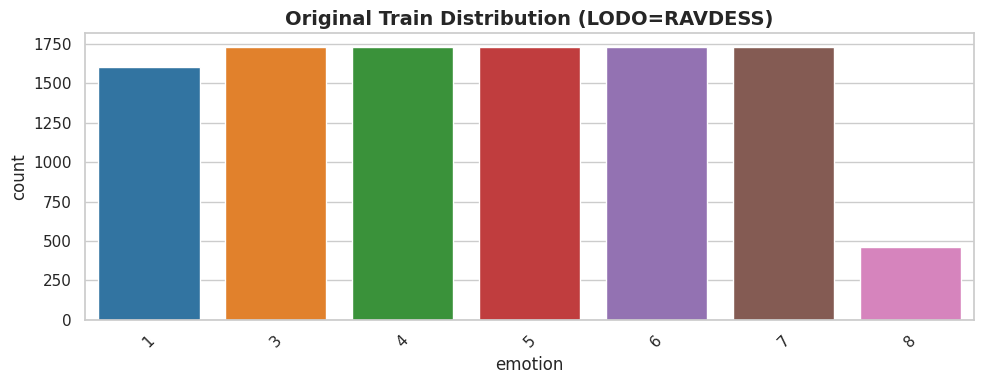


Balancing emotions (LODO=RAVDESS) - IN-MEMORY only...

Before balancing:
emotion
3    1731
4    1731
5    1731
7    1731
6    1731
1    1607
8     460
Name: count, dtype: int64
→ 1: generating 124 aug samples (in-memory)


100%|██████████| 124/124 [00:01<00:00, 86.82it/s] 


→ 8: generating 1271 aug samples (in-memory)


100%|██████████| 1271/1271 [00:03<00:00, 370.66it/s]
/tmp/ipykernel_4441/1507587439.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="emotion", palette="tab10")



After balancing:
emotion
4    1731
3    1731
6    1731
7    1731
5    1731
8    1731
1    1731
Name: count, dtype: int64


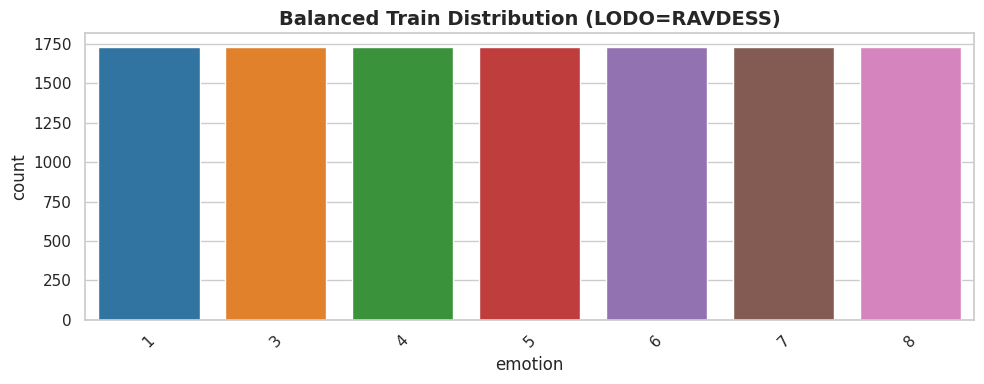


Training Wav2Vec2 — LODO case = RAVDESS


/venv/main/lib/python3.10/site-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Map:   0%|          | 0/10905 [00:00<?, ? examples/s]

Map:   0%|          | 0/1212 [00:00<?, ? examples/s]

Map:   0%|          | 0/2452 [00:00<?, ? examples/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.854418,0.737624
2,No log,0.620998,0.787954
3,No log,0.525168,0.821782
4,No log,0.550403,0.816007
5,No log,0.553352,0.845710
6,No log,0.501822,0.844884
7,No log,0.578761,0.830858
8,No log,0.656853,0.833333
9,No log,0.722077,0.835809
10,No log,0.788482,0.839109



Evaluating model in: Models/LODO_RAVDESS


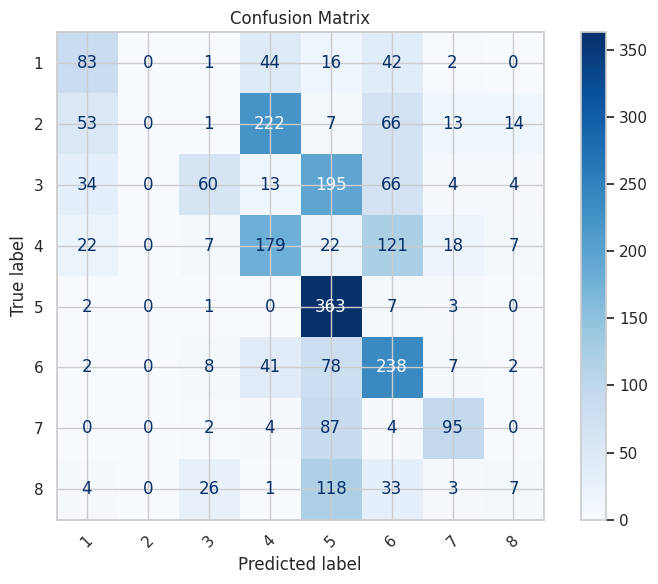

/venv/main/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/venv/main/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/venv/main/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Clearing audio cache for RAVDESS...
Memory freed


LODO CASE: Testing on TESS

Train = 10374, Test = 2800


/tmp/ipykernel_4441/1507587439.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="emotion", palette="tab10")


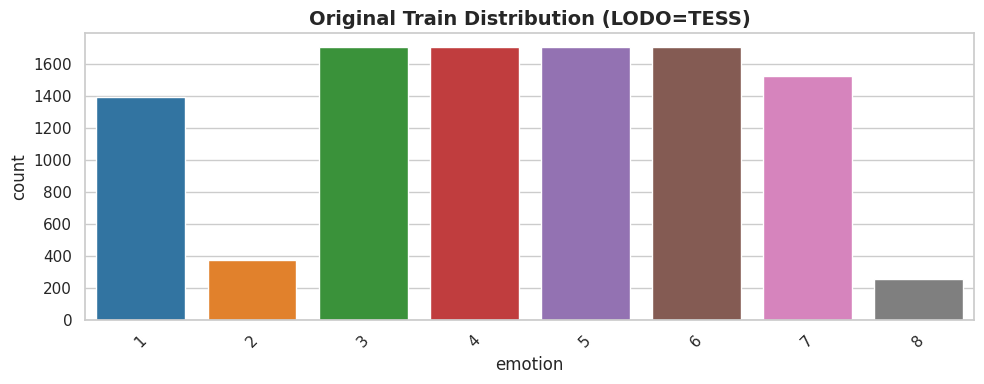


Balancing emotions (LODO=TESS) - IN-MEMORY only...

Before balancing:
emotion
4    1707
3    1707
6    1707
5    1707
7    1523
1    1395
2     376
8     252
Name: count, dtype: int64
→ 7: generating 184 aug samples (in-memory)


100%|██████████| 184/184 [00:00<00:00, 280.20it/s]


→ 1: generating 312 aug samples (in-memory)


100%|██████████| 312/312 [00:01<00:00, 292.40it/s]


→ 2: generating 1331 aug samples (in-memory)


100%|██████████| 1331/1331 [00:04<00:00, 291.41it/s]


→ 8: generating 1455 aug samples (in-memory)


100%|██████████| 1455/1455 [00:04<00:00, 337.17it/s]
/tmp/ipykernel_4441/1507587439.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="emotion", palette="tab10")



After balancing:
emotion
4    1707
7    1707
3    1707
2    1707
6    1707
1    1707
5    1707
8    1707
Name: count, dtype: int64


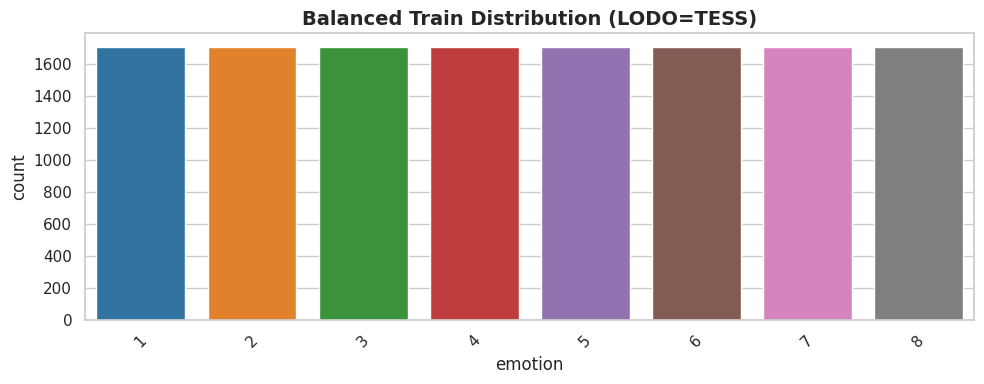


Training Wav2Vec2 — LODO case = TESS


/venv/main/lib/python3.10/site-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Map:   0%|          | 0/12290 [00:00<?, ? examples/s]

Map:   0%|          | 0/1366 [00:00<?, ? examples/s]

Map:   0%|          | 0/2800 [00:00<?, ? examples/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.218951,0.562958
2,No log,0.864518,0.692533
3,No log,0.684880,0.775988
4,No log,0.641786,0.791362
5,No log,0.563544,0.815520
6,No log,0.596373,0.811127
7,No log,0.584401,0.819912
8,No log,0.644265,0.835286
9,No log,0.686448,0.828697
10,No log,0.800087,0.821376



Evaluating model in: Models/LODO_TESS


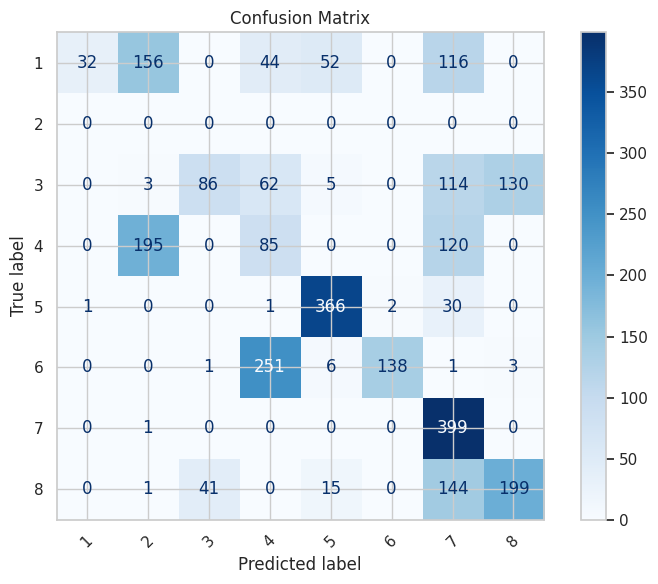

/venv/main/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/venv/main/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/venv/main/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Clearing audio cache for TESS...
Memory freed


LODO CASE: Testing on SAVEE

Train = 12694, Test = 480


/tmp/ipykernel_4441/1507587439.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="emotion", palette="tab10")


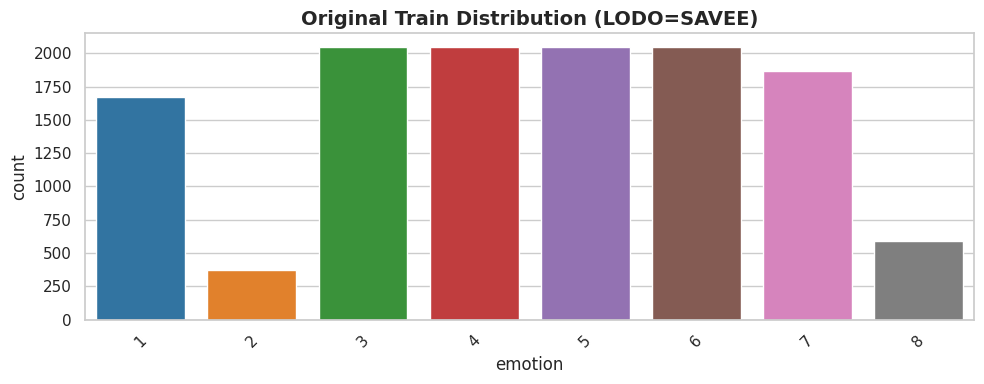


Balancing emotions (LODO=SAVEE) - IN-MEMORY only...

Before balancing:
emotion
4    2047
3    2047
6    2047
5    2047
7    1863
1    1675
8     592
2     376
Name: count, dtype: int64
→ 7: generating 184 aug samples (in-memory)


100%|██████████| 184/184 [00:00<00:00, 269.17it/s]


→ 1: generating 372 aug samples (in-memory)


100%|██████████| 372/372 [00:01<00:00, 338.59it/s]


→ 8: generating 1455 aug samples (in-memory)


100%|██████████| 1455/1455 [00:03<00:00, 368.63it/s]


→ 2: generating 1671 aug samples (in-memory)


100%|██████████| 1671/1671 [00:05<00:00, 298.22it/s]
/tmp/ipykernel_4441/1507587439.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="emotion", palette="tab10")



After balancing:
emotion
5    2047
2    2047
3    2047
8    2047
6    2047
4    2047
1    2047
7    2047
Name: count, dtype: int64


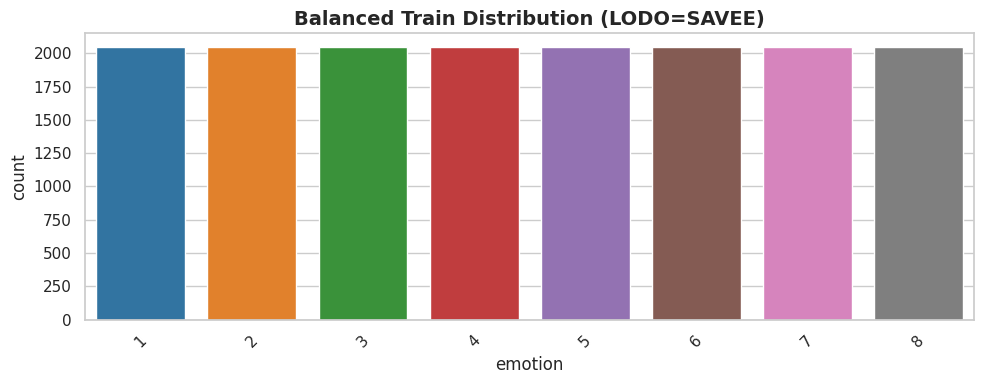


Training Wav2Vec2 — LODO case = SAVEE


/venv/main/lib/python3.10/site-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Map:   0%|          | 0/14738 [00:00<?, ? examples/s]

Map:   0%|          | 0/1638 [00:00<?, ? examples/s]

Map:   0%|          | 0/480 [00:00<?, ? examples/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.811652,0.737485
2,No log,0.618592,0.795482
3,No log,0.565499,0.817460
4,No log,0.437074,0.857143
5,No log,0.535692,0.844322
6,No log,0.461752,0.860806
7,No log,0.705700,0.833333
8,No log,0.626017,0.858974
9,No log,0.638129,0.857143
10,No log,0.731723,0.862027



Evaluating model in: Models/LODO_SAVEE


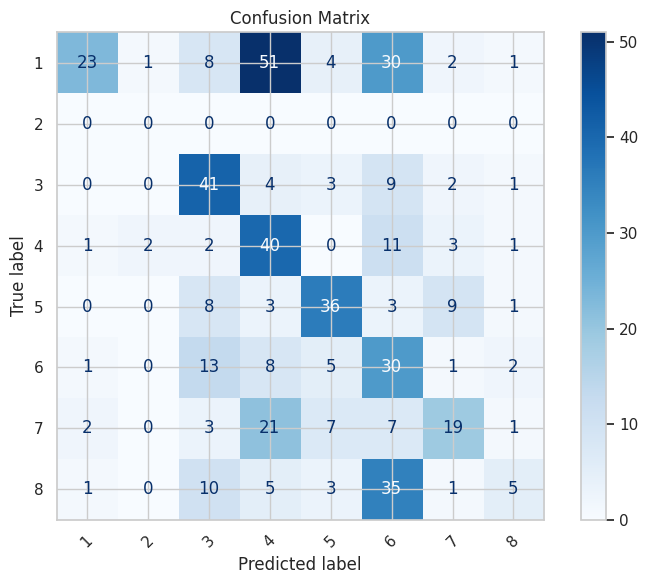

/venv/main/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/venv/main/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/venv/main/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Clearing audio cache for SAVEE...
Memory freed


LODO CASE: Testing on CREMA

Train = 5732, Test = 7442


/tmp/ipykernel_4441/1507587439.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="emotion", palette="tab10")


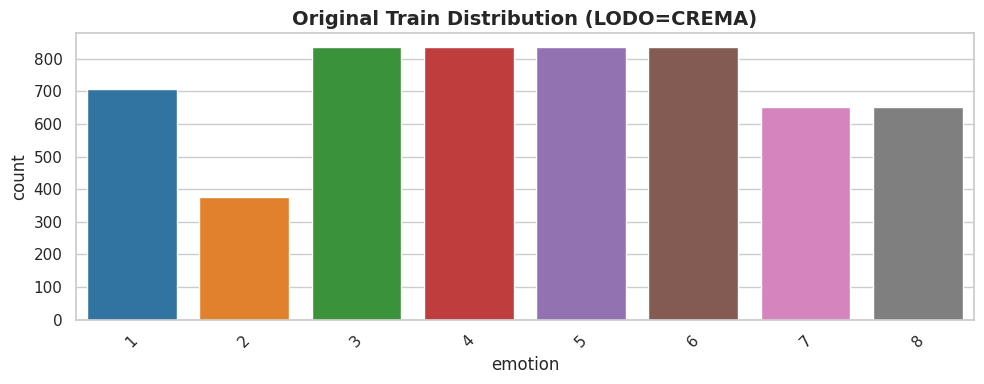


Balancing emotions (LODO=CREMA) - IN-MEMORY only...

Before balancing:
emotion
4    836
3    836
6    836
5    836
1    708
7    652
8    652
2    376
Name: count, dtype: int64
→ 1: generating 128 aug samples (in-memory)


100%|██████████| 128/128 [00:00<00:00, 319.53it/s]


→ 7: generating 184 aug samples (in-memory)


100%|██████████| 184/184 [00:00<00:00, 271.45it/s]


→ 8: generating 184 aug samples (in-memory)


100%|██████████| 184/184 [00:00<00:00, 318.46it/s]


→ 2: generating 460 aug samples (in-memory)


100%|██████████| 460/460 [00:01<00:00, 266.97it/s]
/tmp/ipykernel_4441/1507587439.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="emotion", palette="tab10")



After balancing:
emotion
6    836
1    836
8    836
7    836
2    836
5    836
4    836
3    836
Name: count, dtype: int64


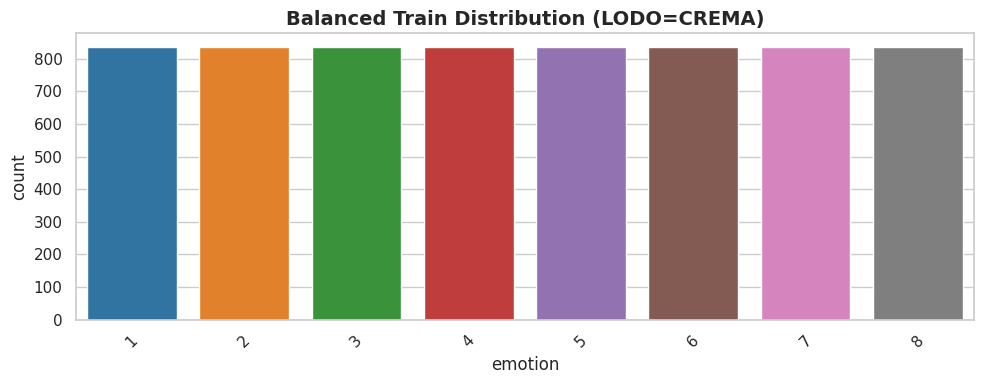


Training Wav2Vec2 — LODO case = CREMA


/venv/main/lib/python3.10/site-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Map:   0%|          | 0/6019 [00:00<?, ? examples/s]

Map:   0%|          | 0/669 [00:00<?, ? examples/s]

Map:   0%|          | 0/7442 [00:00<?, ? examples/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.074221,0.707025
2,No log,0.589384,0.835575
3,No log,0.577980,0.831091
4,No log,0.370009,0.896861
5,No log,0.411805,0.884903
6,No log,0.422776,0.892377
7,No log,0.304140,0.917788
8,No log,0.394896,0.916293
9,No log,0.306183,0.931241
10,No log,0.290843,0.943199



Evaluating model in: Models/LODO_CREMA


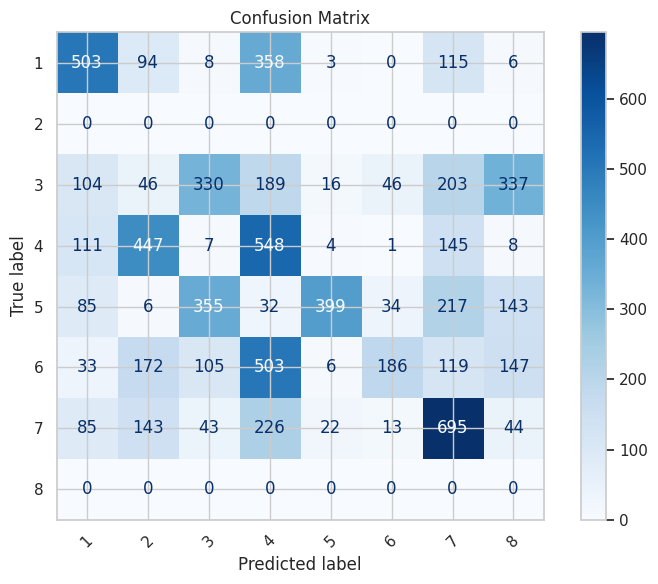

/venv/main/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/venv/main/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/venv/main/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Clearing audio cache for CREMA...
Memory freed


NameError: name 'summary_df' is not defined

In [ ]:
# ========================
# 7. RUN LODO EXPERIMENT 
# ========================
summary_results = []

for test_ds in datasets_all:

    print("\n=========================================")
    print(f"LODO Test = {test_ds}")
    print("=========================================")

    # Clear caches before each LODO case
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # 1. Create LODO split
    train_df = df[df["dataset"] != test_ds].copy()
    test_df  = df[df["dataset"] == test_ds].copy()

    plot_distribution(train_df, f"Before Aug — {test_ds}")

    # 2. Augmentation + balancing
    train_bal, audio_cache = augment_and_balance(train_df)

    plot_distribution(train_bal, f"After Aug — {test_ds}")

    # 3. Train model
    model_dir = run_training(train_bal, test_df, test_ds, audio_cache)

    # 4. Evaluate and save metrics, cm, reports
    metrics = evaluate_model(model_dir, test_df)
    metrics["test_dataset"] = test_ds
    summary_results.append(metrics)

    # clear memory
    audio_cache.clear()
    del audio_cache
    gc.collect()

# ========================
summary_df = pd.DataFrame(summary_results)
summary_df.to_csv("Models/LODO_summary.csv", index=False)

print("\n============= LODO SUMMARY =============")
print(summary_df)

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV if available; otherwise use the values you shared.
csv_candidates = [
    Path("LODO_summary.csv"),
    Path("Results/LODO/LODO_summary.csv"),
    Path("DataFrame/LODO_summary.csv"),
]

csv_path = next((p for p in csv_candidates if p.exists()), None)

if csv_path is not None:
    lodo_df = pd.read_csv(csv_path)
else:
    lodo_df = pd.DataFrame(
        {
            "accuracy": [0.43, 0.40, 0.38, 0.36],
            "precision": [0.38, 0.66, 0.53, 0.53],
            "recall": [0.43, 0.40, 0.38, 0.36],
            "f1": [0.36, 0.37, 0.34, 0.40],
            "test_dataset": ["RAVDESS", "TESS", "SAVEE", "CREMA"],
        }
    )

# Arrange columns and sort by accuracy for easier reading.
lodo_df = lodo_df[["test_dataset", "accuracy", "precision", "recall", "f1"]].sort_values(
    by="accuracy", ascending=False
)

# Create a clean table plot.
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.axis("off")

table_data = lodo_df.copy()
for col in ["accuracy", "precision", "recall", "f1"]:
    table_data[col] = table_data[col].map(lambda x: f"{x:.2f}")

tbl = ax.table(
    cellText=table_data.values,
    colLabels=["Dataset", "Accuracy", "Precision", "Recall", "F1"],
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.1, 1.6)

# Header styling.
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor("#2E5EAA")
    else:
        cell.set_facecolor("#F4F7FC" if row % 2 == 0 else "white")

plt.title("LODO Performance Summary", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

lodo_df